In [ ]:
import numpy as np
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [ ]:
X = np.linspace(0, 10, 200)
y_standard = 3 * X + 5
y = 3 * X + 5 + np.random.normal(0, 2, 200)

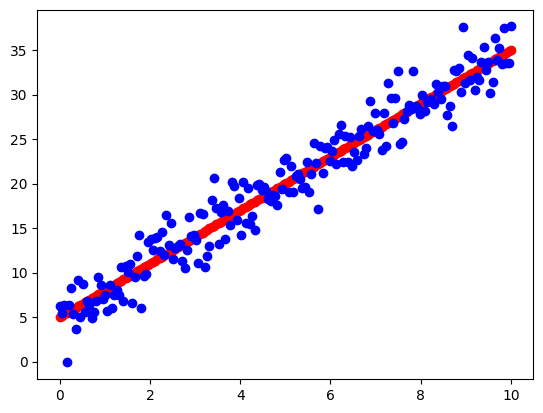

In [ ]:
import matplotlib.pyplot as plt

def my_scatter(X, y1, color1, y2=None, color2=None):
  plt.scatter(X, y1, color=color1)
  if y2 is not None:
    plt.scatter(X, y2, color=color2)

my_scatter(X, y_standard, 'red', y, 'blue')
plt.show()


In [ ]:
model = Sequential(
    [
        Dense(1, input_shape=(1,), activation=None)
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='sgd', loss='mse')

In [ ]:
model.fit(X, y, epochs=5, verbose=1)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 77.7775   
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.1097  
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.6250 
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.4217 
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.1966 


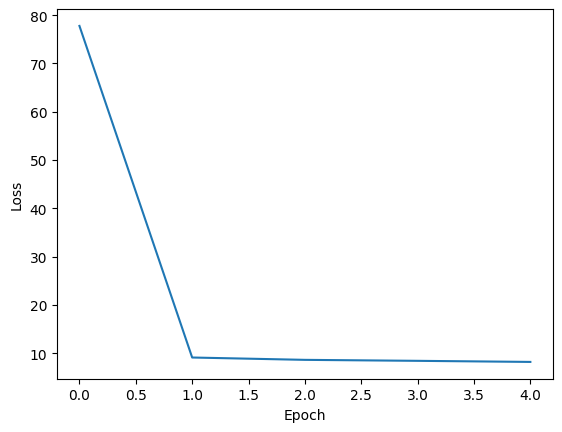

In [ ]:
loss_values = model.history.history['loss']
plt.plot(loss_values)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


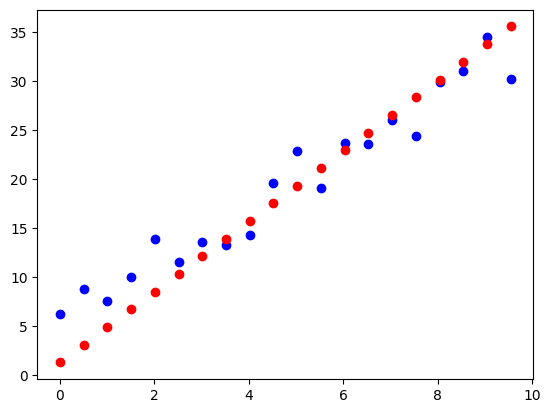

In [ ]:
y_pred = model.predict(X)

my_scatter(X[::10], y[::10], 'blue', y_pred[::10], 'red')

In [ ]:
W, b = model.layers[0].get_weights()

print(W)
print(b)

[[3.595599]]
[1.2479656]


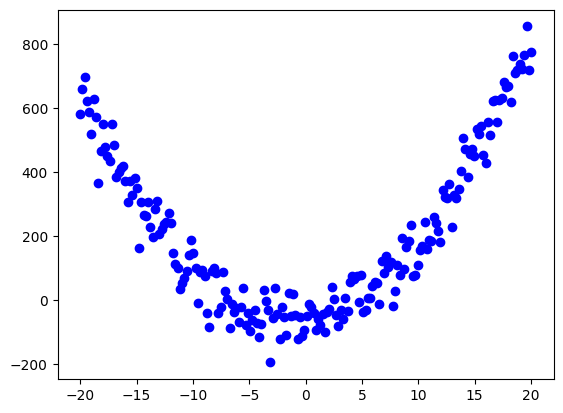

In [ ]:
X = np.linspace(-20, 20, 200)
y = 2*X**2 + 5*X - 10 + np.random.normal(-50, 50, 200)

my_scatter(X, y, 'blue')

In [ ]:
# B1: định nghĩa model
model = Sequential(
    [
        Dense(1, input_shape=(1,), activation="tanh")
    ]
)
# B2: cấu hình model
model.compile(optimizer='sgd', loss='mse')
# B3: huấn luyện
model.fit(X, y, epochs=10, verbose=1)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105536.3984  
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105535.0938
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105532.7422
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105529.4531 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105527.9375 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105527.7031
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105526.5703 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 105524.6406
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105524.8125 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105524.7422 


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


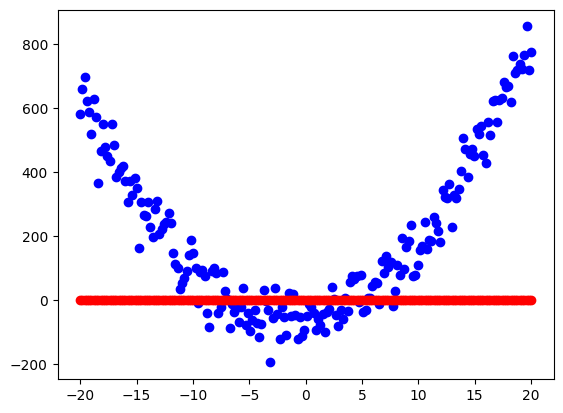

In [ ]:
y_pred = model.predict(X)

my_scatter(X, y, 'blue', y_pred, 'red')

In [ ]:
# B1: định nghĩa model

# Solution 1: toàn relu => y là 2 nhánh đường thẳng
# Solution 2: relu + sigmoid => cong (khó nhận thấy) quanh (0, 1)
# Solution 3: relu + sigmoid + relu => cong nhẹ quanh (0, 1) (do max relu == max sigmoid)
# Solution 4: bổ sung exp để phóng đại kết quả sau relu vượt qua giới hạn trần là 1
model = Sequential(
    [
        Dense(128, input_shape=(1,), activation="relu"),
        Dense(64, activation="sigmoid"),
        Dense(32, activation="relu"),
        Dense(16, activation="exponential"),
        Dense(1, activation=None)
    ]
)
# B2: cấu hình model
model.compile(optimizer='adam', loss='mse')
# B3: huấn luyện
model.fit(X, y, epochs=20, verbose=1)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 104917.1328
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 102892.5703
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 97853.5000 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 81824.9375 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 39755.0117 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20490.6094 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 16324.3691 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9984.3955 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7403.8223  
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6006.3564 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5045.5566 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4688.0713 
Epoch 13/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5313.6499 
Epoch 14/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4640.1187 
Epoch 15/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

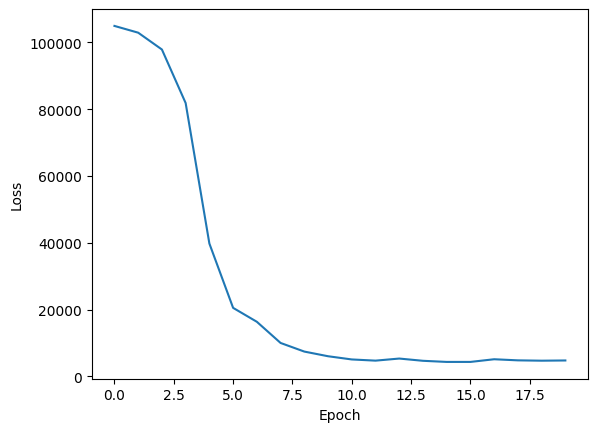

In [ ]:
loss_values = model.history.history['loss']
plt.plot(loss_values)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


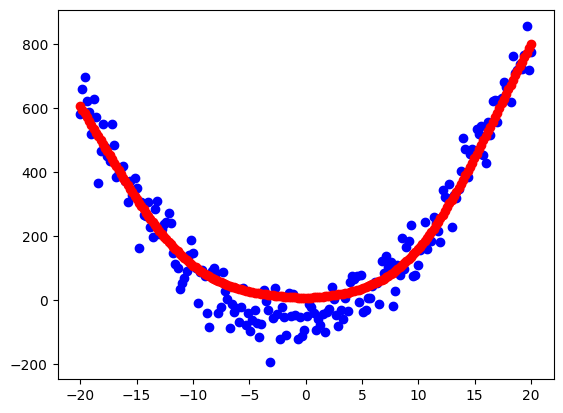

In [ ]:
y_pred = model.predict(X)
my_scatter(X, y, 'blue', y_pred, 'red')

In [ ]:
Weights, b = model.layers[0].get_weights()
print(Weights.shape)
print(b.shape)

(1, 128)
(128,)


In [ ]:
Weights, b = model.layers[1].get_weights()
print(Weights.shape)
print(b.shape)

(128, 64)
(64,)
